 # **Applied Statistics : Titanic Dataset Case Study**

1. Data understanding

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path='/content/drive/MyDrive/Data_Science/Titanic-Dataset.csv'
df=pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
print("Number of rows and columns in titanic dataset is",df.shape)

Number of rows and columns in titanic dataset is (891, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


From this we have noted that 177 entries of age, 687 enries of cabin and 2 enrtries of emabarked is null.

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


So more than 75% data in cabin column is missing so we decided to drop this column

In [ ]:
df.drop('Cabin',axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


As we can see embarkation from S(Southampton) is higher than C(Cherbourg) and Q(Queenstown) so decided to fill null value with S

In [ ]:
# df['Embarked'].fillna('S',inplace=True)
df['Embarked']=df['Embarked'].fillna('S')

Before handling the Age column into mean or median i would like to check the heatmap for age so it cannot be bias.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


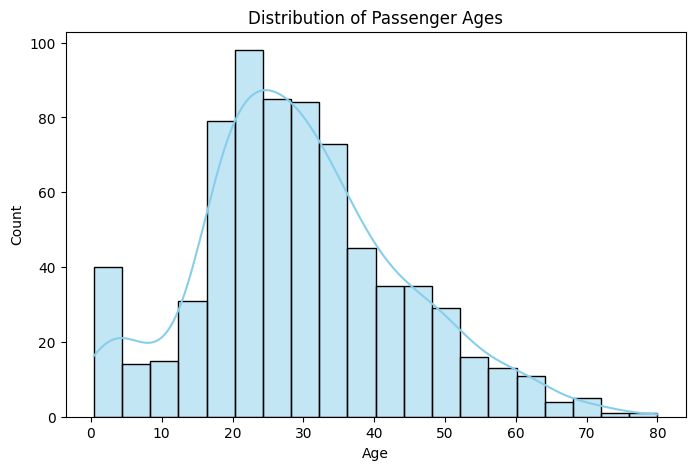

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

As here we can see the curve is right skewed so we are generating  correlation heatmap with numerical data only.

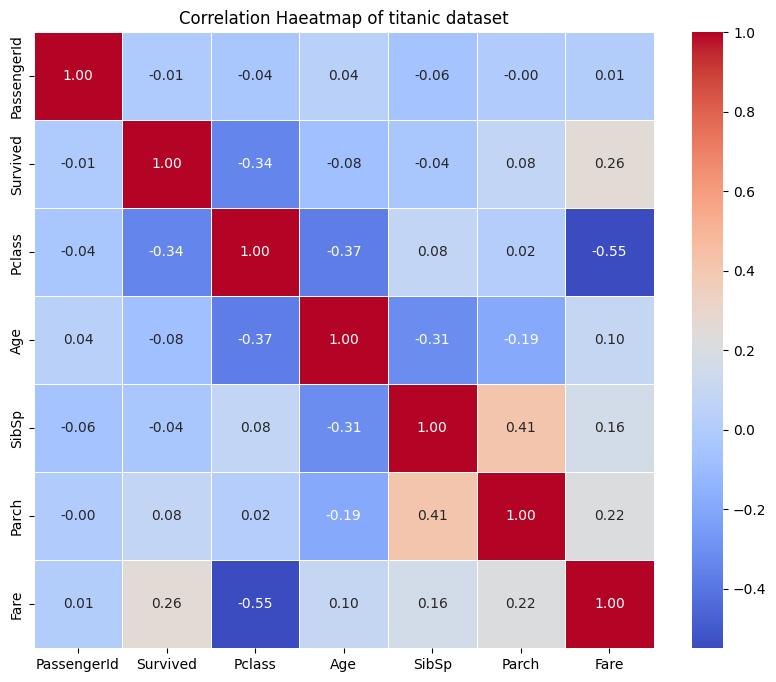

In [ ]:
numerical_df=df.select_dtypes(include=['int64','float64'])
corr_matrix=numerical_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Haeatmap of titanic dataset")
plt.show()

Age has relation with passenger class and sibsp as age goes up pclass also goes down meanse older passenger prefer want first class
So we have decided to group this pclass and sibsp and fill null values with boxplot

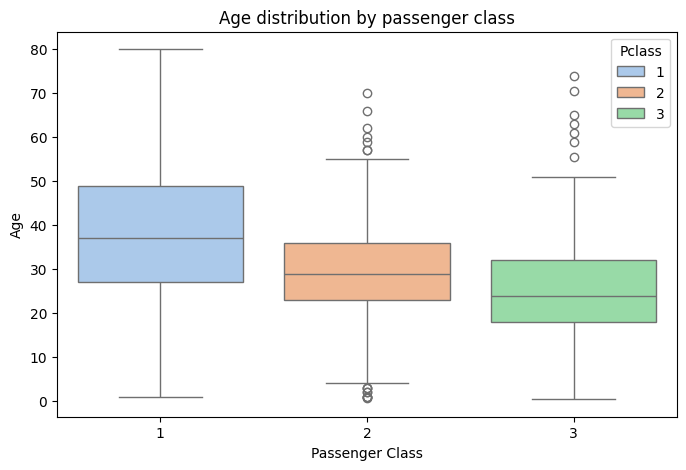

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Pclass',y='Age', data=df, hue='Pclass',palette='pastel')
plt.title("Age distribution by passenger class")
plt.xlabel("Passenger Class")
plt.ylabel("Age")
plt.show()

SO here in box plot we can see that 1st class passenger median is nearly 37 2nd class passenger with 29 and 3rd class passenger with 24.

In [ ]:
def impute_age(cols):
  Age=cols['Age']
  Pclass=cols['Pclass']
  if pd.isnull(Age):
    if Pclass==1:
      return 37
    elif Pclass==2:
      return 29
    else:
      return 24
  else:
    return Age

df['Age']=df[['Age','Pclass']].apply(impute_age,axis=1)



In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
print("Number of duplicate rows in a dataset",df.duplicated().sum())

Number of duplicate rows in a dataset 0


Now its time find outlier

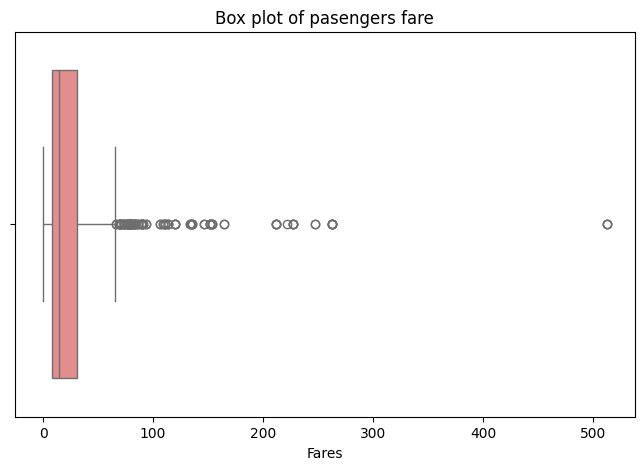

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"], color='Lightcoral')
plt.title("Box plot of pasengers fare")
plt.xlabel("Fares")
plt.show()

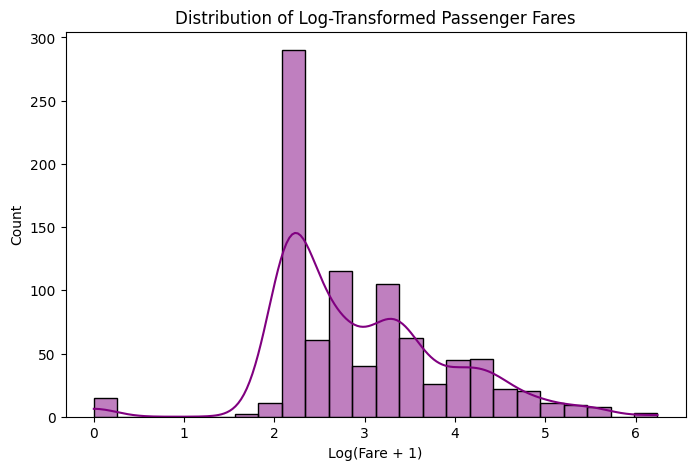

In [ ]:
df['Log_Fare'] = np.log1p(df['Fare'])

plt.figure(figsize=(8, 5))
sns.histplot(df['Log_Fare'], kde=True, color='purple')
plt.title('Distribution of Log-Transformed Passenger Fares')
plt.xlabel('Log(Fare + 1)')
plt.ylabel('Count')
plt.show()

In [ ]:
df['FamilySize']=df["SibSp"]+df["Parch"]+1

In [ ]:
df.drop(columns=['SibSp','Parch'], inplace=True)

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Log_Fare,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,2.110213,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,4.280593,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,2.188856,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,3.990834,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,2.202765,1


Now i have a cleaned dataset so for the use of stakeholder i makes one more dataframe which have removed the confusion of Pclass,Embarked and survived.

In [ ]:
df_clean=df.copy()

In [ ]:
df_clean['Pclass'] = df_clean['Pclass'].map({1:'Upper Class',2:'Middle Class',3:'Lower Class'})
df_clean['Survived']=df_clean['Survived'].map({0:'Died',1:'Survived'})
df_clean['Embarked']=df_clean['Embarked'].map({'S':'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})
df_clean['Sex']=df_clean['Sex'].str.title()

In [ ]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Log_Fare,FamilySize
0,1,Died,Lower Class,"Braund, Mr. Owen Harris",Male,22.0,A/5 21171,7.2500,Southampton,2.110213,2
1,2,Survived,Upper Class,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,PC 17599,71.2833,Cherbourg,4.280593,2
2,3,Survived,Lower Class,"Heikkinen, Miss. Laina",Female,26.0,STON/O2. 3101282,7.9250,Southampton,2.188856,1
3,4,Survived,Upper Class,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,113803,53.1000,Southampton,3.990834,2
4,5,Died,Lower Class,"Allen, Mr. William Henry",Male,35.0,373450,8.0500,Southampton,2.202765,1


EXPLORATORY DATA ANALYSIS

## 1. Demographic Analysis: Gender & Family Size
* **Gender:** Females had a massive survival advantage over males, confirming the enforcement of "women and children first."
* **Family Size:** A non-linear pattern emerged. Solo travelers and large families ($\ge 5$) suffered high mortality rates, while small families (2–4 members) were the "sweet spot" for survival.

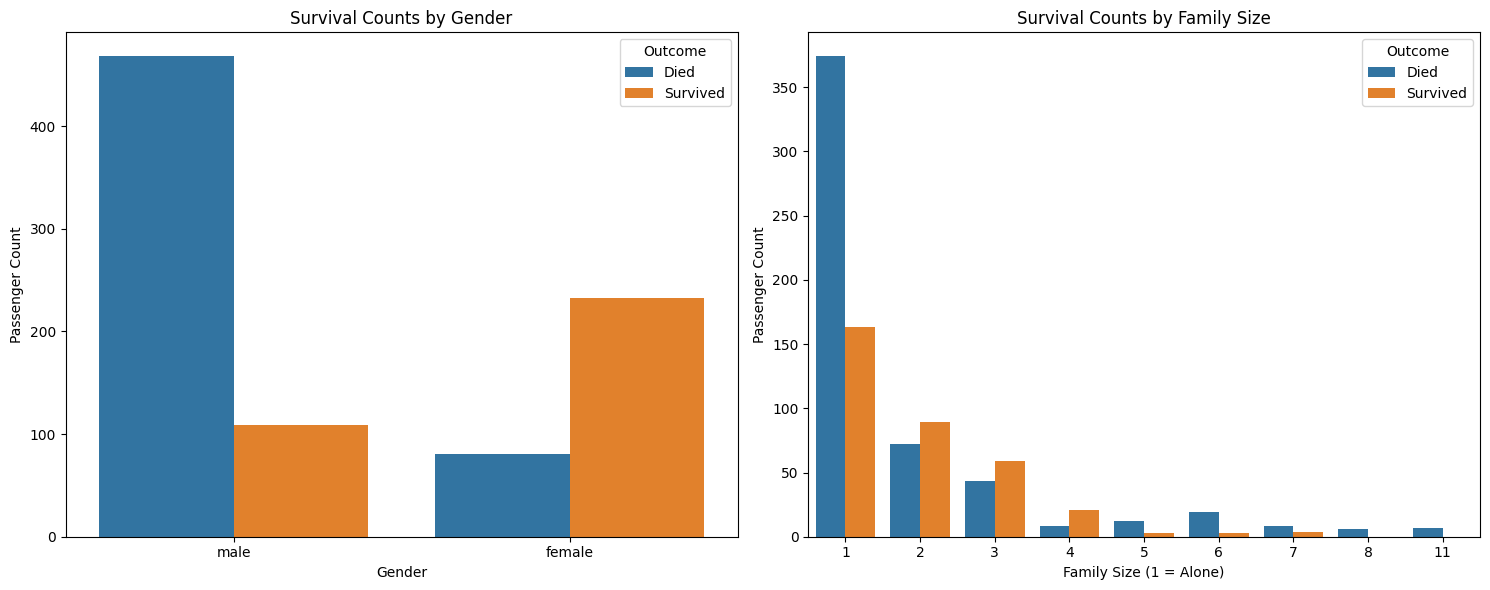

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Survival rate by Gender
sns.countplot(ax=axes[0], x='Sex', hue='Survived', data=df)
axes[0].set_title('Survival Counts by Gender')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Passenger Count')
axes[0].legend(title='Outcome', labels=['Died', 'Survived'])

# Subplot 2: Survival rate by Family Size
sns.countplot(ax=axes[1], x='FamilySize', hue='Survived', data=df)
axes[1].set_title('Survival Counts by Family Size')
axes[1].set_xlabel('Family Size (1 = Alone)')
axes[1].set_ylabel('Passenger Count')
axes[1].legend(title='Outcome', labels=['Died', 'Survived'])

plt.tight_layout()
plt.show()

From this plot we can say that survival rate of female is higher than male. and from second plot it is clear that passenger who are travelling alone has low survival rate and the passenger with 2,3,4 has high survival rate whereas large families cant survive as the orange graph is declining from 5th to 10th family size.

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Log_Fare,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,2.110213,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,4.280593,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,2.188856,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,3.990834,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,2.202765,1


In [ ]:
(df.groupby('Sex')['Survived'].mean()*100).round(2)

,Survived
Sex,
female,74.20
male,18.89


In [ ]:
df.groupby('FamilySize')['Survived'].mean()

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


In [ ]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


Bivarated Analysis

## 2. Socio-Economic Analysis: Passenger Class
* **Class Divide:** 1st-class passengers had the highest probability of survival, while 3rd-class passengers faced a catastrophic number of casualties.
* **The Intersection:** Socio-economic status heavily impacted survival, but gender remained dominant (a 3rd-class female still had a higher survival rate than a 1st-class male).

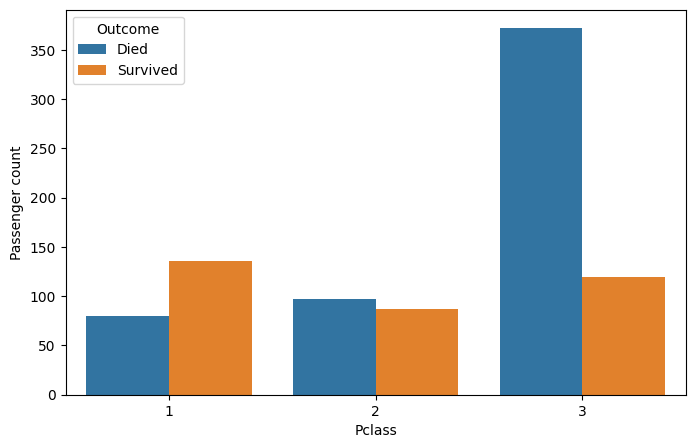

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', hue='Survived',data=df)
plt.title=("Survivrd Count by paseenger class")
plt.xlabel=("Passenger class")
plt.ylabel("Passenger count")
plt.legend(title="Outcome", labels=["Died","Survived"])
plt.show()

First-class passengers exhibited substantially higher survival rates and chances for 2nd class is 50-50 whereas chances od survival of 3rd class is very low.

Multivarated Analysis

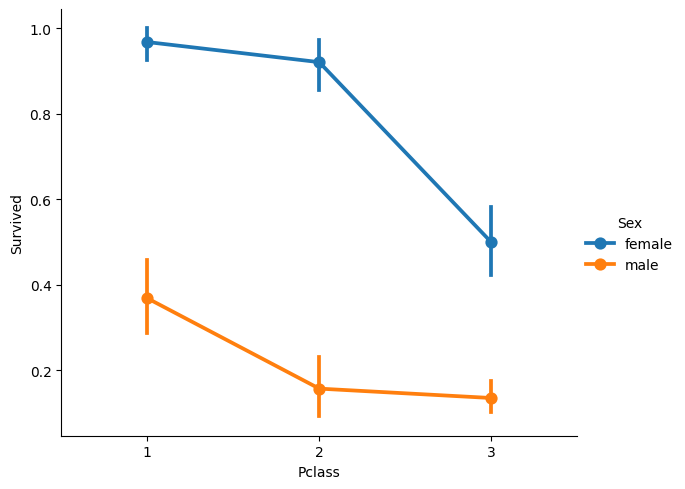

In [ ]:
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='point', data=df, aspect=1.2)
plt.title=('Survival Rates by Passenger Class and Gender')
plt.ylabel=('Survival Probability (0 to 1)')
plt.show()

From this point plot we can coclude gender is highly prioritized to female passenger as there chance to survival is 96-97% whereas male has 37-38%.and futher for 2nd and 3rd class it is dropping out.


Continuous Analysis

## 3. Age Distribution Insights
* **The Childhood Exception:** While adult males faced massive casualties, young boys (ages 0–10) show a clear spike in survival density.
* **Uniform Female Survival:** Age did not heavily restrict female survival; rates remained consistently high across most age brackets.

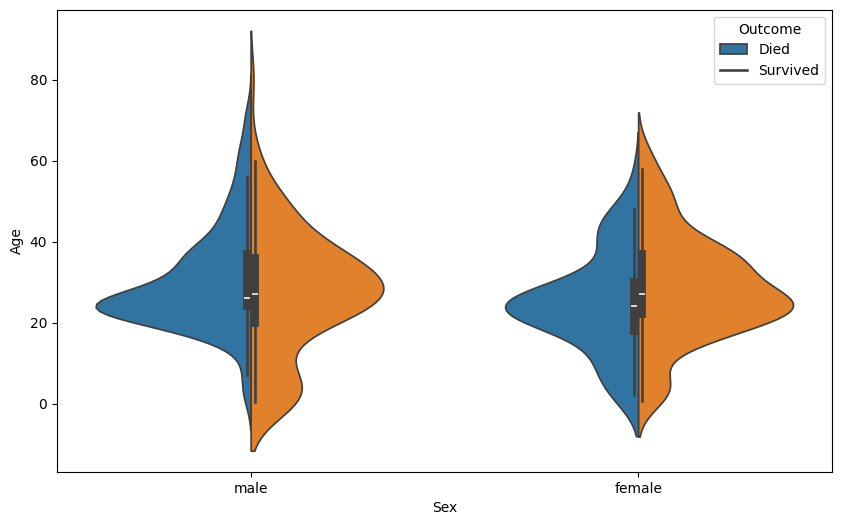

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Sex', y='Age', hue='Survived', data=df, split=True)
plt.title=('Age Distribution by Sex and Survival Status')
plt.xlabel=('Gender')
plt.ylabel=('Age')
plt.legend(title='Outcome', labels=['Died', 'Survived'])
plt.show()

From this violin plot it is clear that child and females are given the higher priority to survive.

As the data is in graphical representation we have to prove it using Hypothesis testing

Null Hypothesis ($H_0$)="Gender and Survival rate are independent"

Alternate Hypothesis ($H_1$)="Gender and Survival rate are dependent"

Significance level ($\alpha$) =0.05

In [ ]:
from scipy import stats

In [ ]:
contigency_table=pd.crosstab(df['Sex'],df['Survived'])
print("Contigeny table of sex and survival \n", contigency_table)

Contigeny table of sex and survival 
 Survived    0    1
Sex               
female     81  233
male      468  109


In [ ]:
chi_2,p_value,dof,expected=stats.chi2_contingency(contigency_table)
print(f"chi2 vlaue : {chi_2:.4f}")
print(f"Pvalue : {p_value}")


chi2 vlaue : 260.7170
Pvalue : 1.1973570627755645e-58


In [ ]:
alpha=0.05
if p_value < alpha:
  print("\n Result : Null hypothesis is rejected")
  print("Conclusion : There is Significant relationship between Gender and Survival")
else:
  print("\n Result: Fail to reject the null hypothesis")
  print("Conclusion: There is no significant relationship between Gender and Survival")


 Result : Null hypothesis is rejected
Conclusion : There is Significant relationship between Gender and Survival


**Null Hypothesis ($H_0$)**="Passenger class is indepented of survival"

**Alternate Hypothesis ($H_1$)**="Passenger Class and survival is associated"

**Significance level ($\alpha$)**=0.05

In [ ]:
contingency_table=pd.crosstab(df['Pclass'],df['Survived'])
print("Contingeny table of passenger class and survival \n", contingency_table)
chi_2,p_value,dof,expected=stats.chi2_contingency(contingency_table)
print(f"chi2 value : {chi_2:.4f}")
print(f"Pvalue : {p_value}")

Contingeny table of passenger class and survival 
 Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119
chi2 value : 102.8890
Pvalue : 4.549251711298793e-23


In [ ]:
if p_value < alpha:
  print("\n Result : Null hypothesis is rejected")
  print("Conclusion : There is Significant relationship between Passenger Class and Survival")
else:
  print("\n Result: Fail to reject the Null hypothesis")
  print("Conclusion: There is no significant relationship between Passenger class and Survival")


 Result : Null hypothesis is rejected
Conclusion : There is Significant relationship between Passenger Class and Survival



**Null Hypothesis ($H_0$):** There is no significant difference between average age of survivor and died.

**Alternative Hypothesis ($H_1$):** Passenger who survived were significantly younger on average than died

**Alpha Level ($\alpha$):** 0.05

In [ ]:
age_survivor=df[df["Survived"] == 1]['Age'].dropna()
age_died=df[df["Survived"]== 0]['Age'].dropna()
print(f"mean of age survival is {age_survivor.mean():.2f} years\n")
print(f"mean of age non survival is {age_died.mean():.2f} years")

mean of age survival is 28.27 years

mean of age non survival is 29.56 years


In [ ]:
t_stat,p_value=stats.ttest_ind(age_survivor, age_died, equal_var=False, alternative='less')
print(f'T Statistic value is {t_stat:.4f}\n')
print(f'P_value is {p_value:.2f}')

T Statistic value is -1.3823

P_value is 0.08


In [ ]:
if p_value < alpha:
  print("\n Result : Null hypothesis is rejected")
  print("Conclusion : The statistically evidence that survival are average of younger age")
else:
  print("\n Result: Fail to reject the Null hypothesis")
  print("Conclusion: The statical evidence that survival are not average of younger age ")


 Result: Fail to reject the Null hypothesis
Conclusion: The statical evidence that survival are not average of younger age 
